# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [14]:
import sys
print(sys.executable)

/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/bin/python


In [15]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"

zsh:1: no such file or directory: /Users/nick/College


In [16]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"

zsh:1: no such file or directory: /Users/nick/College


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score, ConfusionMatrixDisplay

from pathlib import Path
import os

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [18]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [19]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

X = df[feature_names].values
y = df["Class"].values


In [20]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [22]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

In [23]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')], name="baseline_model")

In [24]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_baseline = baseline_model.fit(
    X_train_normalized,
    y_train_categorical,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
)

Epoch 1/20
13/13 [==============================] - 0s 5ms/step - loss: 0.8893 - accuracy: 0.6566 - val_loss: 0.6494 - val_accuracy: 0.9200
Epoch 2/20
13/13 [==============================] - 0s 1ms/step - loss: 0.5656 - accuracy: 0.8889 - val_loss: 0.4522 - val_accuracy: 0.9200
Epoch 3/20
13/13 [==============================] - 0s 991us/step - loss: 0.3772 - accuracy: 0.9495 - val_loss: 0.3228 - val_accuracy: 0.9200
Epoch 4/20
13/13 [==============================] - 0s 991us/step - loss: 0.2617 - accuracy: 0.9495 - val_loss: 0.2402 - val_accuracy: 0.9200
Epoch 5/20
13/13 [==============================] - 0s 1ms/step - loss: 0.1894 - accuracy: 0.9798 - val_loss: 0.1915 - val_accuracy: 0.9200
Epoch 6/20
13/13 [==============================] - 0s 1ms/step - loss: 0.1433 - accuracy: 0.9899 - val_loss: 0.1550 - val_accuracy: 0.9200
Epoch 7/20
13/13 [==============================] - 0s 1ms/step - loss: 0.1094 - accuracy: 1.0000 - val_loss: 0.1332 - val_accuracy: 0.9200
Epoch 8/20
13/13

2/2 [==============================] - 0s 2ms/step - loss: 0.0258 - accuracy: 1.0000
Accuracy 1.0
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



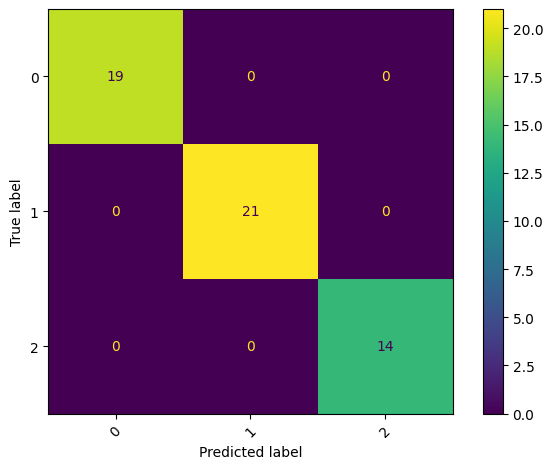

In [93]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

# Classification Report
y_prediction_probabilities = baseline_model.predict(X_test_normalized)
y_predictions = np.argmax(y_prediction_probabilities, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)
_, accuracy = baseline_model.evaluate(X_test_normalized, y_test_categorical)
print("Accuracy",accuracy)
print("Classification Report")
print(classification_report(y_true, y_predictions))

# Confusion matrix
cm = confusion_matrix(y_true, y_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

In [95]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

# Create output directory
OUTPUT_DIR = Path("quantization_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function for saving a TFLite model
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

# Helper function for converting from Keras model to TFLite
def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

baseline_fp32 = convert_to_tflite_fp32(baseline_model)
size_baseline_fp32 = save_binary_model(baseline_fp32, OUTPUT_DIR/"model_base.tflite")
print(size_baseline_fp32)

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp6i7698sf/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp6i7698sf/assets


14.125


2026-05-09 23:18:54.921762: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 23:18:54.921774: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 23:18:54.921867: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp6i7698sf
2026-05-09 23:18:54.922274: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 23:18:54.922278: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp6i7698sf
2026-05-09 23:18:54.923303: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-09 23:18:54.938610: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp6i7698sf
2026-05-

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [96]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]

# Function that returns the representative_data_gen function (helps the converter)
def get_representative_data():
    return representative_data_gen(X_train_normalized)


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = get_representative_data
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        pass

    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
        pass

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        pass

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.

    converted_model = converter.convert()
    file_size_kb = save_binary_model(converted_model, OUTPUT_DIR / filename)

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    interpreter = tf.lite.Interpreter(model_content=converted_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    # Get quantization parameters
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_is_quantized = input_details["dtype"] == np.int8
    output_is_quantized = output_details["dtype"] == np.int8

    y_pred = []
    y_true = np.argmax(y_test_cat, axis=1)

    # Dequantize inputs if needed
    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)
        if input_is_quantized:
            x = np.round(x/input_scale + input_zero_point).astype(np.int8)
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        
        output = interpreter.get_tensor(output_details["index"])
        if output_is_quantized:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        y_pred.append(np.argmax(output))
    y_pred = np.array(y_pred)
        
    # Step 4: Report results.
    print(f"\n{quant_type.upper()} TFLite model size: {file_size_kb:.2f} KB")

    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(xticks_rotation=45)
    plt.tight_layout()
    plt.show()


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp7aifu5pg/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp7aifu5pg/assets



INT8 TFLite model size: 5.80 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-09 19:48:17.665956: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 19:48:17.665971: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 19:48:17.666085: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp7aifu5pg
2026-05-09 19:48:17.666469: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 19:48:17.666473: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp7aifu5pg
2026-05-09 19:48:17.667498: I tensorflow/cc/saved_

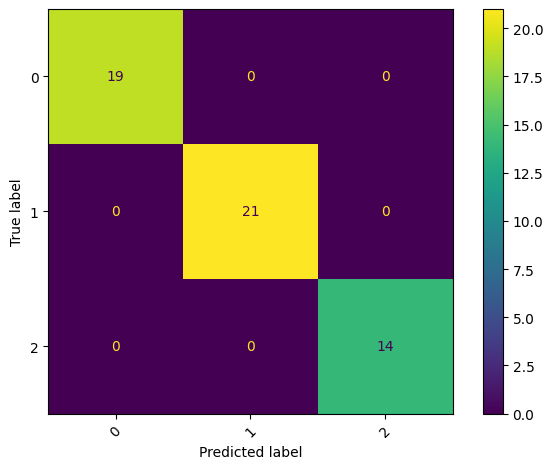

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp478axhx9/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp478axhx9/assets



FLOAT16 TFLite model size: 9.02 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



2026-05-09 19:48:17.995227: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 19:48:17.995237: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 19:48:17.995338: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp478axhx9
2026-05-09 19:48:17.995725: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 19:48:17.995729: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp478axhx9
2026-05-09 19:48:17.996785: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-09 19:48:18.013384: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp478axhx9
2026-05-

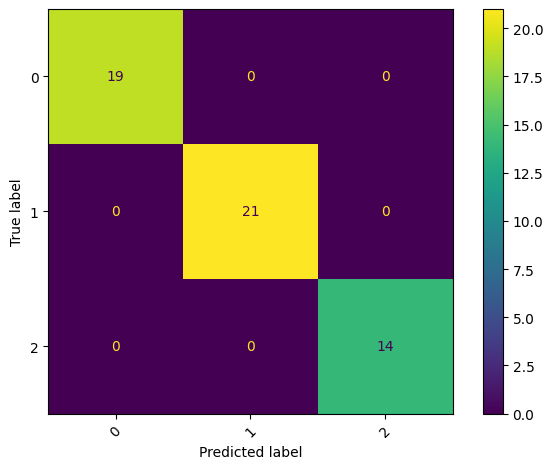

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphqijb39c/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphqijb39c/assets



DYNAMIC TFLite model size: 8.23 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



2026-05-09 19:48:18.284669: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 19:48:18.284679: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 19:48:18.284769: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphqijb39c
2026-05-09 19:48:18.285147: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 19:48:18.285152: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphqijb39c
2026-05-09 19:48:18.286172: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-09 19:48:18.302579: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphqijb39c
2026-05-

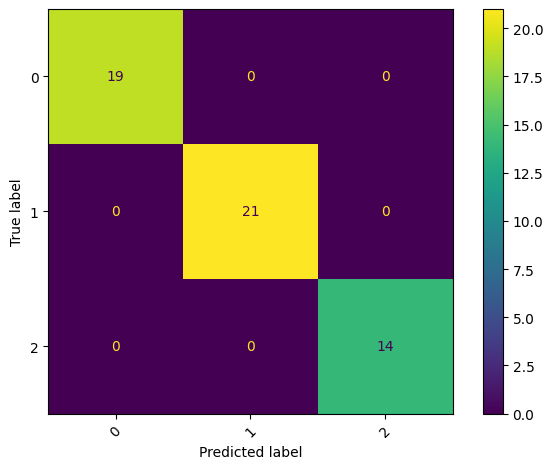

In [32]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
# - 'float16' saved as 'model_float16.tflite'
# - 'dynamic' saved as 'model_dynamic.tflite'

int8 = quantize_and_evaluate(baseline_model, X_test_normalized, y_test_categorical, 'int8', 'model_int8.tflite')
float16 = quantize_and_evaluate(baseline_model, X_test_normalized, y_test_categorical, 'float16', 'model_float16.tflite')
dynamic = quantize_and_evaluate(baseline_model, X_test_normalized, y_test_categorical, 'dynamic', 'model_dynamic.tflite')


## Problem 1 - Part (c)

### Pruning

In [59]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.5,
    final_sparsity=0.7,
    begin_step=0,
    end_step=int(np.ceil(len(X_train_normalized) / 8) * 10))

In [60]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruned_model = Sequential([
    prune_low_magnitude(Dense(64, activation='relu'), pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(32, activation='relu'), pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(3, activation='softmax'), pruning_schedule=pruning_schedule)], name="pruned_model")
pruned_model.build(input_shape=(None, num_features))

In [62]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

pruned_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_pruned = pruned_model.fit(
    X_train_normalized,
    y_train_categorical,
    validation_split=0.2,
    epochs=10,
    batch_size=8,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=1,
)

Epoch 1/10
13/13 [==============================] - 0s 5ms/step - loss: 0.1768 - accuracy: 0.9697 - val_loss: 0.1386 - val_accuracy: 1.0000
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 0.1467 - accuracy: 0.9697 - val_loss: 0.1175 - val_accuracy: 1.0000
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.1246 - accuracy: 0.9697 - val_loss: 0.1044 - val_accuracy: 1.0000
Epoch 4/10
13/13 [==============================] - 0s 1ms/step - loss: 0.1069 - accuracy: 0.9899 - val_loss: 0.0929 - val_accuracy: 1.0000
Epoch 5/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0944 - accuracy: 0.9899 - val_loss: 0.0835 - val_accuracy: 1.0000
Epoch 6/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0835 - accuracy: 0.9899 - val_loss: 0.0760 - val_accuracy: 1.0000
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0769 - accuracy: 0.9899 - val_loss: 0.0715 - val_accuracy: 1.0000
Epoch 8/10
13/13 [==

In [65]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
stripped_model_tflite = converter.convert()
size_stripped_model_tflite = save_binary_model(stripped_model_tflite, OUTPUT_DIR/"model_pruned.tflite")
print(size_stripped_model_tflite)

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpl73jezm5/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpl73jezm5/assets


14.1796875


2026-05-09 20:50:29.905362: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 20:50:29.905372: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 20:50:29.905468: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpl73jezm5
2026-05-09 20:50:29.905727: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 20:50:29.905731: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpl73jezm5
2026-05-09 20:50:29.906348: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-09 20:50:29.912632: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpl73jezm5
2026-05-

2/2 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



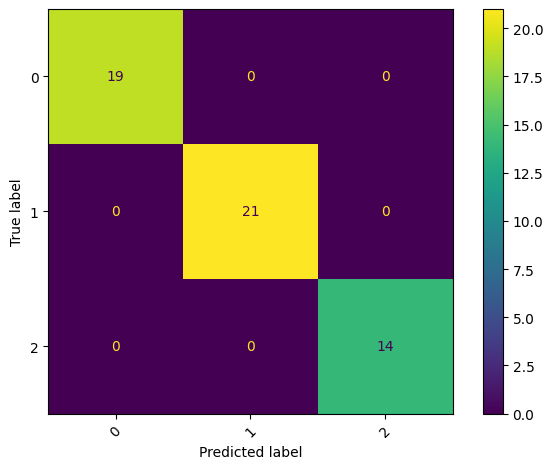

In [66]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

y_prediction_probabilities = stripped_model.predict(X_test_normalized)
y_predictions = np.argmax(y_prediction_probabilities, axis=1)
print(classification_report(y_true, y_predictions))
cm = confusion_matrix(y_true, y_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

## Problem 1 - Part (d)

### Knowledge Distillation

In [81]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

student_model = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')], name="student_model")

In [82]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

teacher_soft_labels = baseline_model.predict(X_train_normalized)

4/4 [==============================] - 0s 951us/step


In [97]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

y_train_combined = np.concatenate([y_train_categorical, teacher_soft_labels], axis=1)

def distillation_loss(y_true_combined, y_pred):

    alpha = 0.5
    y_true_hard = y_true_combined[:, :3]
    y_true_soft = y_true_combined[:, 3:]
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)
    return alpha * hard_loss + (1-alpha) * soft_loss # Combined loss function

In [85]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

student_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=distillation_loss,
    metrics=["accuracy"]
)

student_history = student_model.fit(
    X_train_normalized,
    y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/10
13/13 [==============================] - 0s 5ms/step - loss: 1.0255 - accuracy: 0.5253 - val_loss: 1.0069 - val_accuracy: 0.5200
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 0.8233 - accuracy: 0.6061 - val_loss: 0.8665 - val_accuracy: 0.5600
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.6845 - accuracy: 0.7172 - val_loss: 0.7493 - val_accuracy: 0.6000
Epoch 4/10
13/13 [==============================] - 0s 1ms/step - loss: 0.5654 - accuracy: 0.8485 - val_loss: 0.6412 - val_accuracy: 0.7200
Epoch 5/10
13/13 [==============================] - 0s 964us/step - loss: 0.4710 - accuracy: 0.9293 - val_loss: 0.5414 - val_accuracy: 0.8000
Epoch 6/10
13/13 [==============================] - 0s 965us/step - loss: 0.3890 - accuracy: 0.9697 - val_loss: 0.4603 - val_accuracy: 0.8400
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 0.3209 - accuracy: 0.9697 - val_loss: 0.3927 - val_accuracy: 0.9200
Epoch 8/10
13/13

In [86]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
student_model_tflite = converter.convert()
size_student_model_tflite = save_binary_model(student_model_tflite, OUTPUT_DIR/"model_kd.tflite")
print(size_student_model_tflite)

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphgvm9nja/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphgvm9nja/assets


6.15234375


2026-05-09 22:13:35.939426: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 22:13:35.939435: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 22:13:35.939533: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphgvm9nja
2026-05-09 22:13:35.939891: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 22:13:35.939895: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphgvm9nja
2026-05-09 22:13:35.940826: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-09 22:13:35.954919: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphgvm9nja
2026-05-

2/2 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        19
           1       1.00      0.81      0.89        21
           2       0.92      0.86      0.89        14

    accuracy                           0.89        54
   macro avg       0.90      0.89      0.89        54
weighted avg       0.91      0.89      0.89        54



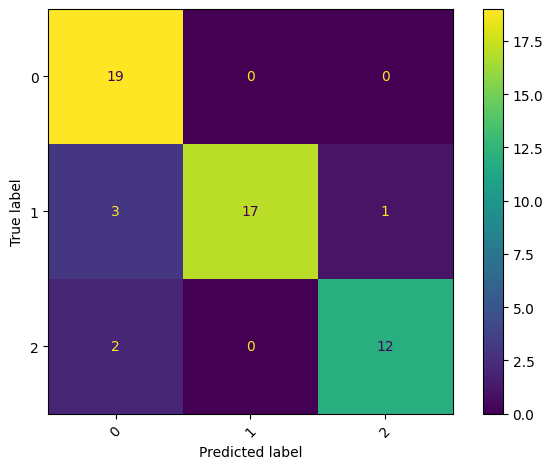

In [87]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

y_prediction_probabilities = student_model.predict(X_test_normalized)
y_predictions = np.argmax(y_prediction_probabilities, axis=1)
print(classification_report(y_true, y_predictions))
cm = confusion_matrix(y_true, y_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


Epoch 1/10
13/13 [==============================] - 0s 6ms/step - loss: 0.1279 - accuracy: 0.9798 - val_loss: 0.1762 - val_accuracy: 0.9600
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 0.1005 - accuracy: 0.9798 - val_loss: 0.1484 - val_accuracy: 0.9600
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0852 - accuracy: 0.9899 - val_loss: 0.1284 - val_accuracy: 0.9600
Epoch 4/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0741 - accuracy: 0.9899 - val_loss: 0.1156 - val_accuracy: 0.9600
Epoch 5/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0663 - accuracy: 0.9899 - val_loss: 0.1053 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0605 - accuracy: 0.9899 - val_loss: 0.1024 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 0.0562 - accuracy: 1.0000 - val_loss: 0.0983 - val_accuracy: 0.9600
Epoch 8/10
13/13 [==

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcxb_dwqd/assets



INT8 TFLite model size: 3.69 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-09 23:01:24.844437: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-09 23:01:24.844445: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-09 23:01:24.844546: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcxb_dwqd
2026-05-09 23:01:24.844781: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-09 23:01:24.844785: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcxb_dwqd
2026-05-09 23:01:24.845346: I tensorflow/cc/saved_

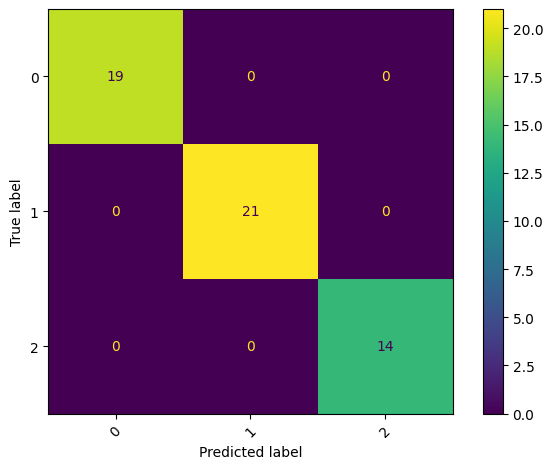

In [92]:
# Prune the already trained student model
pruned_student_model = prune_low_magnitude(student_model, pruning_schedule=pruning_schedule)
pruned_student_model.build(input_shape=(None, num_features))

pruned_student_model.compile(
    optimizer="adam",
    loss=distillation_loss,
    metrics=["accuracy"],
)

# Train the pruned student model with the combined labels
history_pruned_student = pruned_student_model.fit(
    X_train_normalized,
    y_train_combined,
    validation_split=0.2,
    epochs=10,
    batch_size=8,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=1,
)

# Strip the pruned student model
stripped_student_model = tfmot.sparsity.keras.strip_pruning(pruned_student_model)

# Quantize the stripped pruned student model
int8_stripped_student_model = quantize_and_evaluate(stripped_student_model, X_test_normalized, y_test_categorical, 'int8', 'model_int8_stripped_student_model.tflite')

# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
